# تحويل هوف للخطوط:


## الهدف:

** في هذا الفصل :**

* سنفهم مفهوم تحويل هوف

* سنرى كيفية استخدامه لاكتشاف الخطوط في الصورة .

* سنرى التوابع التالية: ** cv2.HoughLines , cv2.HoughLinesP **

# النظرية:

تحويل هوف hough  هو تقنية شائعة لاكتشاف اي جسم يمكن تمثيل شكله بمعادلة رياضية , حيث يمكنه الاكتشاف حتى ان كان الجسم متقطعاً ..

حيث يمكن تمثيل خط بالمعادلة *y = mx+c* او بشكل بارامتري : $$\rho = x\;cos(\theta) + y\;sin(\theta) $$ حيث  $\rho$ هو المسافة العامودية من المبدأ على المستقيم  , و $\theta$ هي الزاوية بين هذا المستقيم العمودي والمحور الافقي مقاساً بعكس عقارب الساعة , وهذا هو التمثيل المستخدم في OpenCV.



والان لشرح التحويل , اولا ً علينا تمثيل كل مستقيم وفق بارامترين $(\rho,\theta)$ ولذلك ننشأ مراكماً ببعدين , لتمثيل القيمتين , ونصفره بالبداية , وحجم هذه المصفوفة تعتمد على الدقة التي تريدها , ولدقة تساوي 1 درجة نحتاج 180 سطراً , وكذلك لدقة واحد بكسل نحتاج اعمدة مساوية لقطر الصورة ..

ولنعتبر لدينا , صورة 100X100 مع خط افقي بالوسط ,  ,مع معرفة الاحداثيات لنقطة فيه يمكننا تعويض قيم الزوايا وايجاد قيم $\rho$ الموافقة وزيادة الخلية الموافقة بمقدار 1. 

وهكذا للنقاط الاخرى بالمستقيم , وعملياً نكون ** نصوت ** لفرضيات مستقيم يمر من تلك النقاط , وهكذا فان المستقيم ذو القيم الاعلى بالنهاية , يتم رسمه و أخذه كخرج لهذه الخوارزمية .

وهذه هي كيفية عمل , تحويل هوف , ويمكن تطبيقه ايضاً بوساطة Numpy  وتظهر القيم المختارة في المراكم اذا مثلناه كصورة رمادية كنقاط ذروة بيضاء

## تحويل هوف في OpenCV:

كل ما تم شرحه سابقاً يوجد بالتابع , **cv2.HoughLines** . وهو يعيد ببساطة  مصفوفة قيم , $(\rho,\theta)$ حيث يقاس البعد بالبكسلات و الزوايا بالراديان , .

البارامتر الاول , هو صورة الدخل الثنائية , ولذلك يجب تطبيق مكتشف حواف اولاً ككاني على الصورة , والثاني هو الدقة المطلوبة ل $\rho$ و $\theta$ على الترتيب , والرابع هو العتبة للتصويت الاصغري لاعتباره مستقيماً , وهذا ايضاً يعني الطول الاصغر للمستقيم المقبول , وفيما يلي مثال:

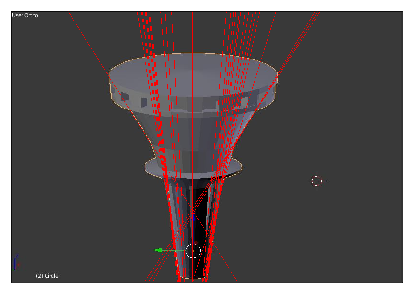

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

img = cv2.imread('wt.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

edges = cv2.Canny(gray,50,150,apertureSize = 3)

lines = cv2.HoughLines(edges,1,np.pi/180,95)
for rho,theta in lines[0]:
    # the next still the same Nomater What..
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    
    cv2.line(img,(x1,y1),(x2,y2),(255,0,0),1)
    

plt.figure(figsize=(10,5))
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()

## تحويل هوف الاحتمالي:

في تحويل هوف السابق , لاحظنا انه حتى لاكتشاف مستقيم ببارامترين انجزنا الكثير من الحسابات , على كل هناك تحسين لهذا التقنية ويتم بأخذ مجموعة نقاط عشوائية , بدلا عن النقاط كلها وهذا لن يؤثر على الناتج ,فقط علينا تخفيض العتبة 

** تطبيق OpenCV لهذا قائم على اكتشاف الخطوط القوي , باستخدام تحويل هوف التقدمي الاحتمالي **

* **minLineLength** - الطول الاصغري للمستقيم , ويرفض كل ما دونه.

* **maxLineGap** -   المسافة الاعظمية المسموحة بين اجزاء الخط لاعتباره خطاً واحد



وافضل ما في الامر انه يعطي نقطتي النهاية للمستقيم وليس بارامتراته  , وهذا يحدده اكثر.
كالتالي

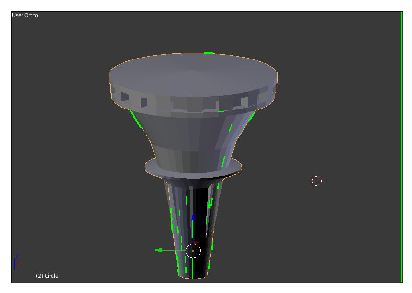

In [2]:
img = cv2.imread('wt.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

edges = cv2.Canny(gray,50,150,apertureSize = 3)
minLineLength = 100
maxLineGap = 10
lines = cv2.HoughLinesP(edges,1,np.pi/180,85,
                        minLineLength,maxLineGap)
for x1,y1,x2,y2 in lines[0]:
    cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)
    
plt.figure(figsize=(10,5))
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()

## مراجع اضافية :

** تمارين **

# تحويل هوف الدائري:

## الهدف:

** سنتعلم بهذا الفصل: **

* تحويل هوف لايجاد الدوائر في الصورة.

* سنرى هذه التوابع **cv2.HoughCircles **

## النظرية:
المركز يتمثل رياضياً كالتالي $$(x - x_{center} )^2 + (y - y_{center})^2 = r^2 $$ حيث $(x_{center},y_{center})$  هو مركز الدائرة, و $r$ هو نصف القطر . ونلاحظ هنا وجود 3 بارامترات وبالتالي يصعب بناء مراكم لها , ولذلك يستخدم OpenCV **طريقة هوف للتدرج ** والتي تستخدم معلومات الميل للحواف.

وسنستخدم هنا التابع **cv2.HoughCircles ** والذي لديه الكثير من المتغيرات , والتالي البرنامج:

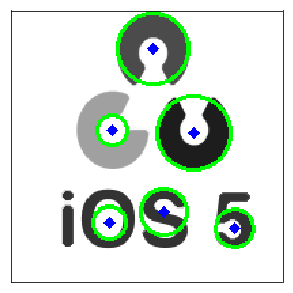

In [3]:
img = cv2.imread('opencv_ios.png',0)
img = cv2.medianBlur(img,5)
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

circles = cv2.HoughCircles(img,cv2.cv.CV_HOUGH_GRADIENT,1,20,
                           param1=50,param2=30,minRadius=0,
                           maxRadius=0)

circles = np.uint16(np.around(circles))
for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(cimg,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    cv2.circle(cimg,(i[0],i[1]),2,(0,0,255),3)
    
plt.figure(figsize=(10,5))
plt.imshow(cimg)
plt.xticks([])
plt.yticks([])
plt.show()

رغم ان النتيجة ليست , مثالية , لكنها جيدة ..

### مراجع اضافية 

### تمارين: